# Students
## Behnoud Shafiezadeh Kenari (ID : 5655740) 
## Erfan Fathi (ID : 5652154)

In [1]:
# importing libraries
import os, glob
os.environ["SM_FRAMEWORK"] = "tf.keras"
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
import cv2
from keras.optimizers import Adam
from tensorflow import keras
import segmentation_models as sm
from keras.callbacks import ModelCheckpoint
from tensorflow import keras

2023-06-25 17:42:48.955134: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2023-06-25 17:42:49.050576: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2023-06-25 17:42:49.559462: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


Segmentation Models: using `tf.keras` framework.


In [2]:
# defining different backbones

#BACKBONE = 'vgg16'
#BACKBONE = 'vgg19'
#BACKBONE = 'resnet18'
#BACKBONE = 'resnet34'
BACKBONE = 'resnet50'
#BACKBONE = 'densenet121'
#BACKBONE = 'densenet169'
#BACKBONE = 'densenet201'
#BACKBONE = 'efficientnetb0'
#BACKBONE = 'efficientnetb1'
#BACKBONE = 'efficientnetb2'
#BACKBONE = 'efficientnetb3'
#BACKBONE = 'mobilenet' 
#BACKBONE = 'mobilenetv2'

preprocess_input = sm.get_preprocessing(BACKBONE)

#Resize images (height  = X, width = Y)
SIZE_X = 384 
SIZE_Y = 384

In [3]:
# paths for .png images and masks
#Capture training images and masks info as a list
train_images = []

for directory_path in glob.glob("/home/behnoud/Desktop/Desktop/data/slices/img2"):
    for img_path in sorted(glob.glob(os.path.join(directory_path, "*.png"))):
        img = cv2.imread(img_path, cv2.IMREAD_COLOR)       
        train_images.append(img)

#Convert list to array for machine learning processing        
train_images = np.array(train_images)

#Capture mask/label info as a list
train_masks = [] 
for directory_path in glob.glob("/home/behnoud/Desktop/Desktop/data/slices/mask2"):
    for mask_path in sorted(glob.glob(os.path.join(directory_path, "*.png"))):
        mask = cv2.imread(mask_path, 0)       
        train_masks.append(mask)

#Convert list to array for machine learning processing          
train_masks = np.array(train_masks)

In [4]:
#Constructing image (input) and mask (output)
X = train_images
Y = train_masks.astype(float)
Y = np.expand_dims(Y, axis=3)

#binarize Y mask to two values 0 and 1
#as sum pixels we have more than two labels in some images, we assign them to label 1
Y [Y == 254.] = 255.
Y = Y/255.

print(X.shape)
print(Y.shape)

(160, 384, 384, 3)
(160, 384, 384, 1)


In [5]:
# spilitting data to train and validation set
from sklearn.model_selection import train_test_split
x_train, x_val, y_train, y_val = train_test_split(X, Y, test_size=0.2, random_state=42)
x_test,_,y_test,_= train_test_split(x_val, y_val, test_size=0.5, random_state=42)

# preprocess input data
x_train = preprocess_input(x_train)
x_val = preprocess_input(x_val)

#create model and using sigmoid as we have binary classification in our output
model = sm.Unet(BACKBONE, classes=1, activation='sigmoid')

2023-06-25 17:43:15.842583: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:996] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2023-06-25 17:43:15.903704: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:996] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2023-06-25 17:43:15.903828: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:996] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysf

In [7]:
# define optomizer
LR= 0.0001
optim = keras.optimizers.Adam(LR)

# Segmentation models losses can be combined together by '+' and scaled by integer or float factor
dice_loss = sm.losses.DiceLoss()
focal_loss = sm.losses.BinaryFocalLoss()
total_loss = dice_loss + (1 * focal_loss)

metrics = [sm.metrics.IOUScore(threshold=0.5), sm.metrics.FScore(threshold=0.5)]

# compile keras model with defined optimozer, loss and metrics
model.compile(optim, total_loss, metrics)

In [8]:
# fitting the model
history=model.fit(x_train, 
          y_train,
          batch_size=4, 
          epochs=20,
          verbose=1,
          validation_data=(x_val, y_val))

Epoch 1/20


2023-06-25 17:43:46.595155: I tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:424] Loaded cuDNN version 8600
2023-06-25 17:43:47.271555: I tensorflow/tsl/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2023-06-25 17:43:50.268750: I tensorflow/compiler/xla/service/service.cc:169] XLA service 0x7f53896e76d0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2023-06-25 17:43:50.268770: I tensorflow/compiler/xla/service/service.cc:177]   StreamExecutor device (0): NVIDIA GeForce RTX 3060 Laptop GPU, Compute Capability 8.6
2023-06-25 17:43:50.282119: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2023-06-25 17:43:50.370369: I tensorflow/tsl/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2023-06-25 17:43:50.412774: I ./tensorflow/compiler/jit/

32/32 [==============================] - ETA: 0s - loss: 0.9825 - iou_score: 0.2521 - f1-score: 0.3666

2023-06-25 17:44:12.231400: I tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:637] TensorFloat-32 will be used for the matrix multiplication. This will only be logged once.
2023-06-25 17:44:13.027566: W tensorflow/tsl/framework/bfc_allocator.cc:296] Allocator (GPU_0_bfc) ran out of memory trying to allocate 3.24GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
2023-06-25 17:44:13.027612: W tensorflow/tsl/framework/bfc_allocator.cc:296] Allocator (GPU_0_bfc) ran out of memory trying to allocate 3.24GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.


32/32 [==============================] - 34s 241ms/step - loss: 0.9825 - iou_score: 0.2521 - f1-score: 0.3666 - val_loss: 1.6998 - val_iou_score: 0.0438 - val_f1-score: 0.0838
Epoch 2/20
32/32 [==============================] - 5s 168ms/step - loss: 0.8619 - iou_score: 0.6033 - f1-score: 0.7430 - val_loss: 1.1858 - val_iou_score: 0.1164 - val_f1-score: 0.2076
Epoch 3/20
32/32 [==============================] - 5s 168ms/step - loss: 0.7997 - iou_score: 0.7026 - f1-score: 0.8181 - val_loss: 0.8864 - val_iou_score: 0.5479 - val_f1-score: 0.7057
Epoch 4/20
32/32 [==============================] - 5s 168ms/step - loss: 0.7484 - iou_score: 0.7475 - f1-score: 0.8522 - val_loss: 0.8305 - val_iou_score: 0.5823 - val_f1-score: 0.7335
Epoch 5/20
32/32 [==============================] - 5s 169ms/step - loss: 0.7105 - iou_score: 0.7467 - f1-score: 0.8496 - val_loss: 0.7478 - val_iou_score: 0.7648 - val_f1-score: 0.8649
Epoch 6/20
32/32 [==============================] - 5s 169ms/step - loss: 0.6602

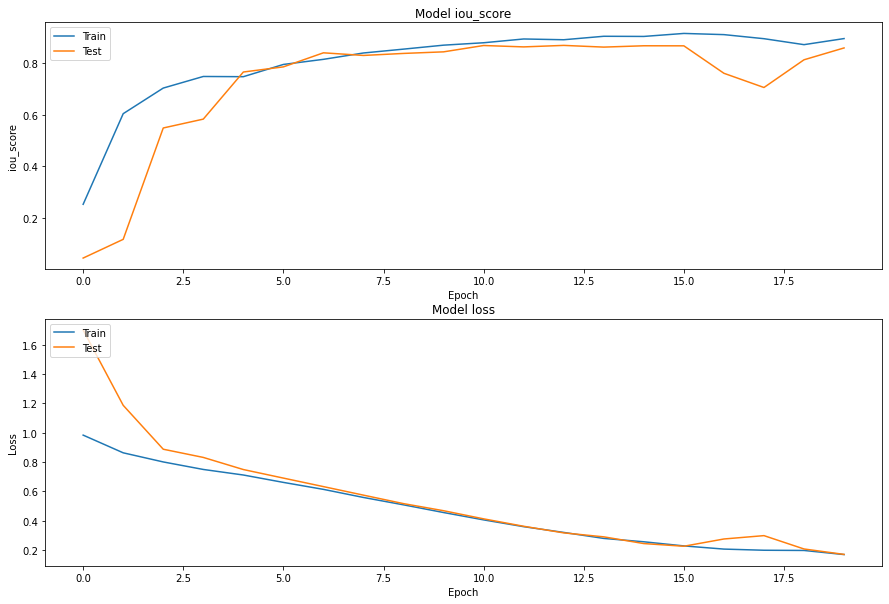

In [9]:
# Plot training & validation iou_score values
plt.figure(figsize=(15, 10))
plt.subplot(211)
plt.plot(history.history['iou_score'])
plt.plot(history.history['val_iou_score'])
plt.title('Model iou_score')
plt.ylabel('iou_score')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')

# Plot training & validation loss values
plt.subplot(212)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()

In [10]:
model.save('resnet50.h5')

1/1 [==============================] - 1s 1s/step


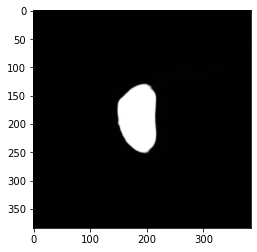

In [11]:
model = keras.models.load_model('resnet50.h5',compile=False)

#Test on a different image
#READ EXTERNAL IMAGE and preprocess it
test_img = cv2.imread('/home/behnoud/Desktop/Desktop/data/slices/img2/prostat4-slice010_z.png', cv2.IMREAD_COLOR)       
test_img = cv2.resize(test_img, (SIZE_Y, SIZE_X))
test_img = cv2.cvtColor(test_img, cv2.COLOR_RGB2BGR)
test_img = np.expand_dims(test_img, axis=0)

# predicting trined model on test image
prediction = model.predict(test_img)

#View and Save segmented image
prediction_image = prediction.reshape(mask.shape)
plt.imshow(prediction_image, cmap='gray')
plt.imsave('/home/behnoud/Desktop/Desktop/data/slices/predicted4-slice010_z.png', prediction_image, cmap='gray')


In [13]:
# define optomizer
LR= 0.0001
optim = keras.optimizers.Adam(LR)

# Segmentation models losses can be combined together by '+' and scaled by integer or float factor
dice_loss = sm.losses.DiceLoss()
focal_loss = sm.losses.BinaryFocalLoss()
total_loss = dice_loss + (1 * focal_loss)

metrics = [sm.metrics.IOUScore(threshold=0.5), sm.metrics.FScore(threshold=0.5)]

# compile keras model with defined optimozer, loss and metrics
model.compile(optim, total_loss, metrics)


score = model.evaluate(x_test, y_test, verbose=1)

2023-06-25 17:51:06.972561: W tensorflow/tsl/framework/bfc_allocator.cc:296] Allocator (GPU_0_bfc) ran out of memory trying to allocate 7.47GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
2023-06-25 17:51:06.972623: W tensorflow/tsl/framework/bfc_allocator.cc:296] Allocator (GPU_0_bfc) ran out of memory trying to allocate 7.47GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
2023-06-25 17:51:07.598100: W tensorflow/tsl/framework/bfc_allocator.cc:296] Allocator (GPU_0_bfc) ran out of memory trying to allocate 3.89GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
2023-06-25 17:51:08.487443: W tensorflow/tsl/framework/bfc_allocator.cc:296] Allocator (GPU

1/1 [==============================] - 10s 10s/step - loss: 0.1624 - iou_score: 0.8650 - f1-score: 0.9276
